<a href="https://colab.research.google.com/github/saranyareddy77/MDS-LAB/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

In [28]:
df = pd.read_csv('advertising.csv')

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [29]:
X = df[['TV']]
y = df['Sales']

print("X = TV Advertising")
print("Y = Sales")
print("Number of rows:", len(df))

X = TV Advertising
Y = Sales
Number of rows: 200


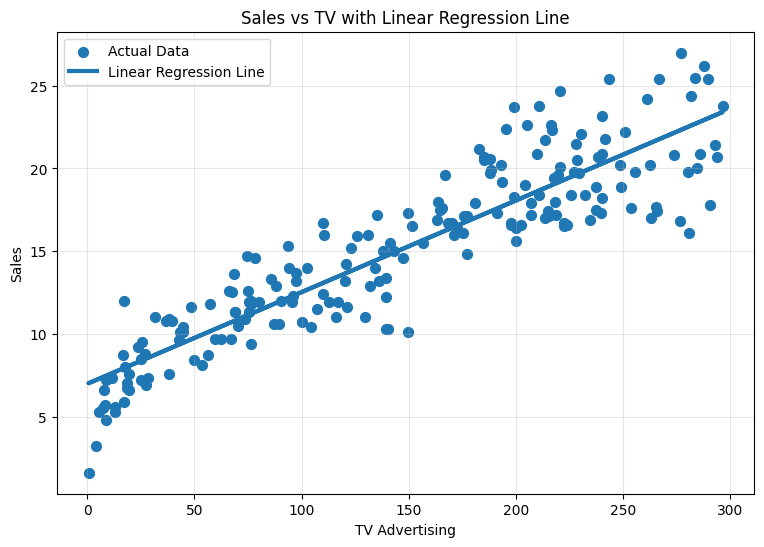

In [31]:
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(9,6))

plt.scatter(
    df['TV'],
    df['Sales'],
    s=50,
    label='Actual Data'
)

plt.plot(
    df['TV'],
    y_pred,
    linewidth=3,
    label='Linear Regression Line'
)

plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Sales vs TV with Linear Regression Line')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [32]:
r2 = r2_score(y, y_pred)

print("Linear Regression Equation:")
print(f"Sales = {model.intercept_:.4f} + ({model.coef_[0]:.4f} × TV)")

print("\nR² Score:", round(r2, 4))

Linear Regression Equation:
Sales = 6.9748 + (0.0555 × TV)

R² Score: 0.8122


In [33]:
residuals = y - y_pred

df['Predicted_Sales'] = y_pred
df['Residuals'] = residuals

df[['TV', 'Sales', 'Predicted_Sales', 'Residuals']].head(10)

,TV,Sales,Predicted_Sales,Residuals
0,230.1,22.1,19.737265,2.362735
1,44.5,10.4,9.443004,0.956996
2,17.2,12.0,7.928816,4.071184
3,151.5,16.5,15.377734,1.122266
4,180.8,17.9,17.002852,0.897148
5,8.7,7.2,7.457365,-0.257365
6,57.5,11.8,10.164046,1.635954
7,120.2,13.2,13.641687,-0.441687
8,8.6,4.8,7.451819,-2.651819
9,199.8,15.6,18.056683,-2.456683


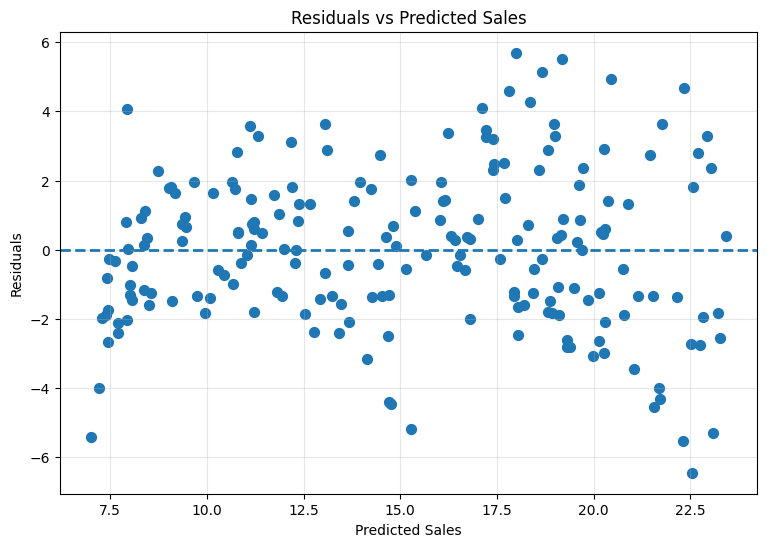

In [34]:
plt.figure(figsize=(9,6))

plt.scatter(
    y_pred,
    residuals,
    s=50
)

plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Sales')

plt.grid(True, alpha=0.3)
plt.show()

In [35]:
df['Standardized_Residuals'] = stats.zscore(residuals)

df[['TV', 'Sales', 'Residuals', 'Standardized_Residuals']].head(10)

,TV,Sales,Residuals,Standardized_Residuals
0,230.1,22.1,2.362735,1.034364
1,44.5,10.4,0.956996,0.418956
2,17.2,12.0,4.071184,1.782294
3,151.5,16.5,1.122266,0.491309
4,180.8,17.9,0.897148,0.392756
5,8.7,7.2,-0.257365,-0.112670
6,57.5,11.8,1.635954,0.716192
7,120.2,13.2,-0.441687,-0.193363
8,8.6,4.8,-2.651819,-1.160920
9,199.8,15.6,-2.456683,-1.075493


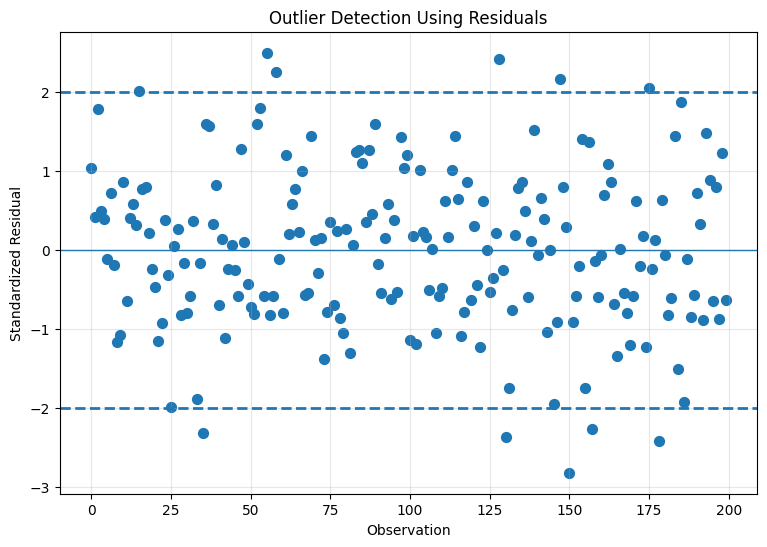

In [36]:
plt.figure(figsize=(9,6))

plt.scatter(
    df.index,
    df['Standardized_Residuals'],
    s=50
)

plt.axhline(2, linestyle='--', linewidth=2)
plt.axhline(-2, linestyle='--', linewidth=2)
plt.axhline(0, linewidth=1)

plt.xlabel('Observation')
plt.ylabel('Standardized Residual')
plt.title('Outlier Detection Using Residuals')

plt.grid(True, alpha=0.3)
plt.show()

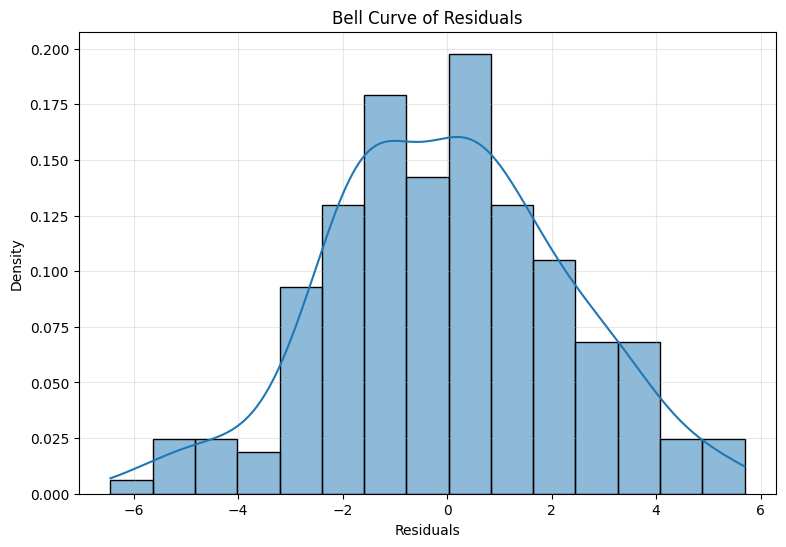

In [37]:
plt.figure(figsize=(9,6))

sns.histplot(
    residuals,
    bins=15,
    kde=True,
    stat='density'
)

plt.xlabel('Residuals')
plt.ylabel('Density')
plt.title('Bell Curve of Residuals')

plt.grid(True, alpha=0.3)
plt.show()

In [38]:
normalized_residuals = (
    residuals - residuals.mean()
) / residuals.std()

print("Mean:", normalized_residuals.mean())
print("Standard Deviation:", normalized_residuals.std())

Mean: 8.881784197001253e-18
Standard Deviation: 0.9999999999999997


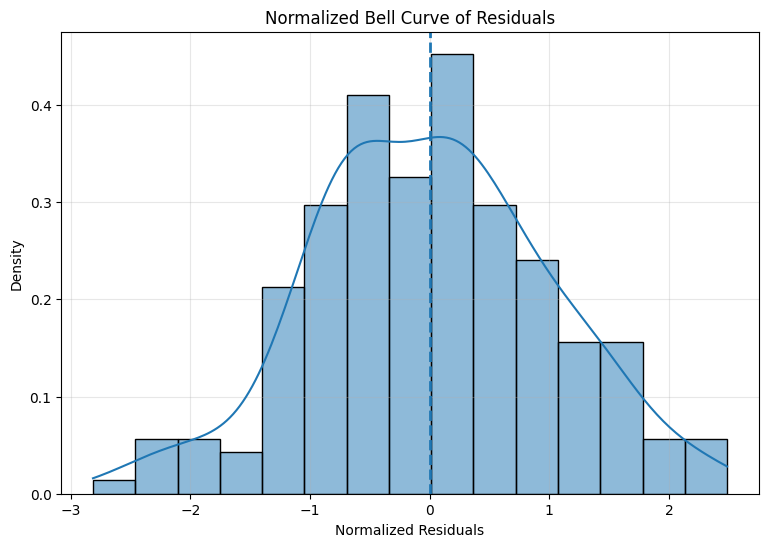

In [39]:
plt.figure(figsize=(9,6))

sns.histplot(
    normalized_residuals,
    bins=15,
    kde=True,
    stat='density'
)

plt.axvline(
    0,
    linestyle='--',
    linewidth=2
)

plt.xlabel('Normalized Residuals')
plt.ylabel('Density')
plt.title('Normalized Bell Curve of Residuals')

plt.grid(True, alpha=0.3)
plt.show()

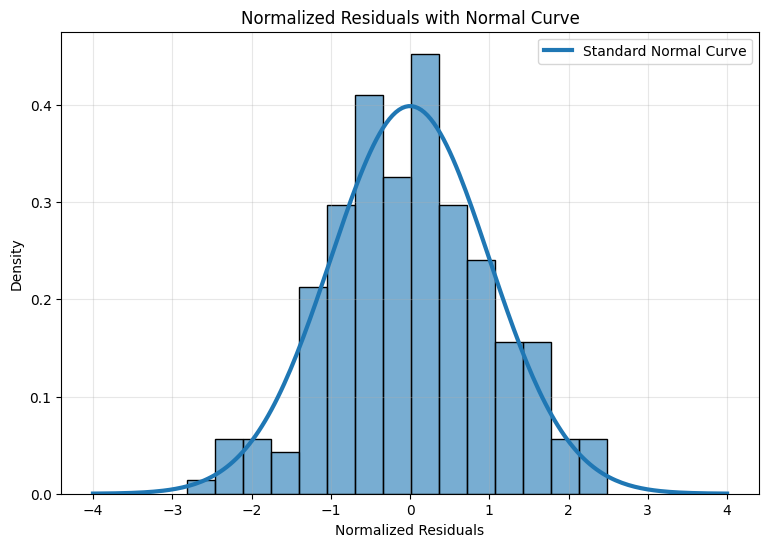

In [40]:
plt.figure(figsize=(9,6))

sns.histplot(
    normalized_residuals,
    bins=15,
    stat='density',
    alpha=0.6
)

x = np.linspace(-4, 4, 200)

normal_curve = stats.norm.pdf(x, 0, 1)

plt.plot(
    x,
    normal_curve,
    linewidth=3,
    label='Standard Normal Curve'
)

plt.xlabel('Normalized Residuals')
plt.ylabel('Density')
plt.title('Normalized Residuals with Normal Curve')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

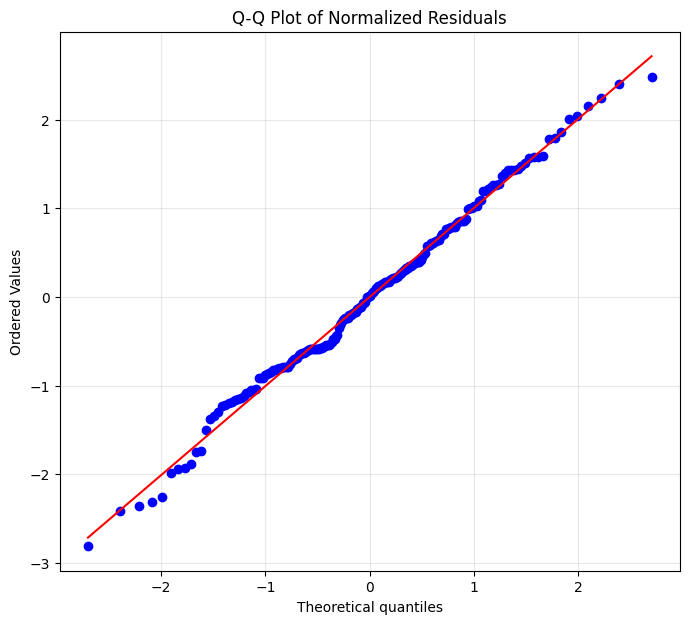

In [41]:
plt.figure(figsize=(8,7))

stats.probplot(
    normalized_residuals,
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot of Normalized Residuals')
plt.grid(True, alpha=0.3)

plt.show()

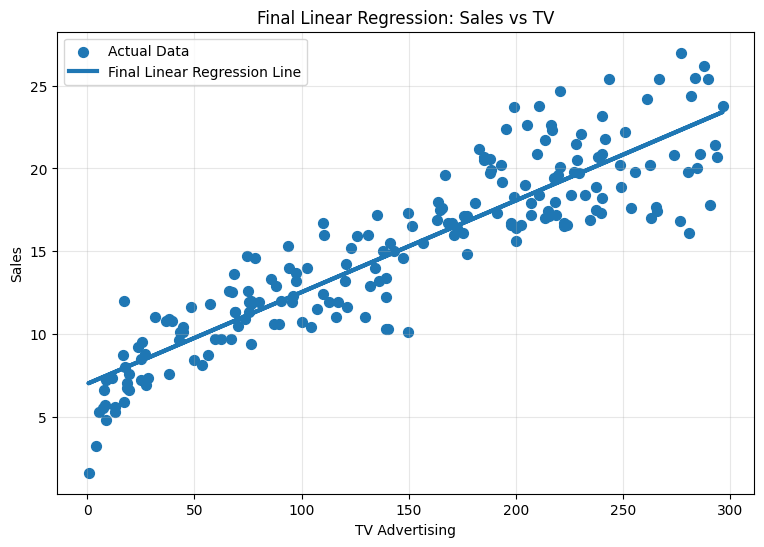

In [42]:
plt.figure(figsize=(9,6))

plt.scatter(
    df['TV'],
    df['Sales'],
    s=50,
    label='Actual Data'
)

plt.plot(
    df['TV'],
    y_pred,
    linewidth=3,
    label='Final Linear Regression Line'
)

plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.title('Final Linear Regression: Sales vs TV')

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [43]:
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("FINAL RESULTS")
print("-" * 40)

print(f"Regression Equation:")
print(f"Sales = {model.intercept_:.4f} + ({model.coef_[0]:.4f} × TV)")

print(f"\nR² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

print(f"\nMean Residual: {residuals.mean():.6f}")
print(f"Number of Outliers: {len(outliers)}")

FINAL RESULTS
----------------------------------------
Regression Equation:
Sales = 6.9748 + (0.0555 × TV)

R² Score: 0.8122
MSE: 5.2177
RMSE: 2.2842

Mean Residual: -0.000000
Number of Outliers: 3
